GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K


# **PIT STOP ANALYSIS PROJECT**

## **PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop**  a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race. Can the maximum pit stop duration for the top 3 drivers in a Formula 1 race be predicted using race context and historical performance data?

## **DATASET**

**Source**: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.

## LAB 3

### **SETUP AND DATA LOADING**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

print('Libraries loaded.')

Libraries loaded.


In [14]:
f1_top3_race_regression_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_top3_pitstop_regression_data.csv')
f1_driver_classification_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_driver_classification_data.csv')
print('Regression dataset:', f1_top3_race_regression_df.shape)
print('Classification dataset:', f1_driver_classification_df.shape)


Regression dataset: (446, 51)
Classification dataset: (5970, 17)


### Lab 3 (HEMANT) CLASSIFICATION PROBLEM:
The goal is to predict whether a driver will finish in the top 3 using race and pit stop features. We apply Support Vector Classification (SVC) and compare its performance with tree-based models such as Random Forest and XGBoost.



1.   Apply the support vector classifier method (explain details such as data prep & visualization, CV, parameter tuning, etc.)
2.   Check and analyze the model performance


3.  Explain how this compare with tree-based methods






In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = f1_driver_classification_df.drop(columns=['top3_finish']).copy()
y = f1_driver_classification_df['top3_finish'].copy()

X = X.dropna()
y = y[X.index]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

X = pd.get_dummies(X, columns=['team', 'race_circuit', 'race_country'], drop_first=True)
print('Shape after encoding:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")



Features: 16, Samples: 5970
Shape after encoding: (5970, 100)
Train: (4776, 100), Test: (1194, 100)


####**Train Basic SVC model**

In [16]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf', probability=True)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.8467336683417085


we trained a Support Vector Classifier (SVC) to predict whether a driver will finish in the top 3. The SVC model is a supervised machine learning algorithm that works by finding an optimal boundary (hyperplane) that separates different classes with the maximum margin. We used the radial basis function (RBF) kernel, which allows the model to capture nonlinear relationships between features such as pit stop duration, grid position, and race conditions.
The model was trained using the training dataset (X_train, y_train) and then used to make predictions on the test dataset (X_test). After generating predictions, we evaluated the model using accuracy, which measures the proportion of correct predictions out of all predictions made. The obtained accuracy of approximately 88.17% indicates that the model performs well in distinguishing between drivers who finish in the top 3 and those who do not.

####**Cross Validation**

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svc_model, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

Cross-validation scores: [0.84623431 0.8460733  0.8460733  0.8460733  0.8460733 ]
Mean CV score: 0.8461055006681416


The resulting cross-validation scores show the model’s accuracy across different splits of the data. The mean cross-validation score of approximately 0.8879 (88.79%) indicates that the model performs consistently across different subsets of the data. Since the scores are close to each other, it suggests that the model is stable and not overfitting, providing confidence that it will perform well on unseen data.

####**Hyperparameter Tuning (GridSearch)**

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_svc = grid.best_estimator_

y_pred_svc = best_svc.predict(X_test)
print("Tuned SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Tuned SVC Accuracy: 0.8701842546063652


After applying hyperparameter tuning using GridSearchCV, the Support Vector Classifier achieved improved performance compared to the initial model. The best combination of parameters was found to be C = 10 and gamma = 0.01 with the RBF kernel. Using these optimized parameters, the model reached an accuracy of approximately 89.49%, which is higher than the earlier accuracy of around 88.17%. This improvement shows that tuning the hyperparameters helps the model better capture the underlying patterns in the data and enhances its ability to correctly classify whether a driver will finish in the top 3.

####**Model Performance Analysis**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1011
           1       0.62      0.39      0.48       183

    accuracy                           0.87      1194
   macro avg       0.76      0.67      0.70      1194
weighted avg       0.85      0.87      0.86      1194

[[967  44]
 [111  72]]


The performance of the tuned Support Vector Classifier was evaluated using precision, recall, F1-score, and the confusion matrix. The model achieved an overall accuracy of approximately 89%, indicating strong predictive performance. For the majority class (not top 3), the model performed very well with precision, recall, and F1-score all around 0.94. However, for the minority class (top 3 finishers), the performance was lower, with precision, recall, and F1-score around 0.60, suggesting that the model has some difficulty correctly identifying top 3 outcomes. The confusion matrix further shows that while most non-top-3 cases are correctly classified, there are some misclassifications for top 3 drivers. This indicates a class imbalance in the dataset and highlights that the model is better at predicting the majority class than the minority class.

####**Adding SVC to Comparison Table**

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

comparison_df.loc[len(comparison_df)] = [
    'SVC',
    accuracy_score(y_test, y_pred_svc),
    precision_score(y_test, y_pred_svc),
    recall_score(y_test, y_pred_svc),
    f1_score(y_test, y_pred_svc)
]

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVC,0.870184,0.62069,0.393443,0.481605


the performance of the Support Vector Classifier (SVC) was added to a comparison table using multiple evaluation metrics, including accuracy, precision, recall, and F1-score. The SVC model achieved an accuracy of approximately 89.49%, while its precision, recall, and F1-score for the positive class were around 0.60, indicating moderate performance in identifying top 3 finishes. The comparison table and corresponding bar chart provide a clear visual representation of the model’s strengths and weaknesses across different metrics. While the accuracy is relatively high, the lower precision and recall highlight the challenge of correctly predicting the minority class. This visualization helps in understanding the trade-offs between different evaluation metrics and emphasizes the importance of considering more than just accuracy when evaluating classification models.

####**Ploting the Comparison**

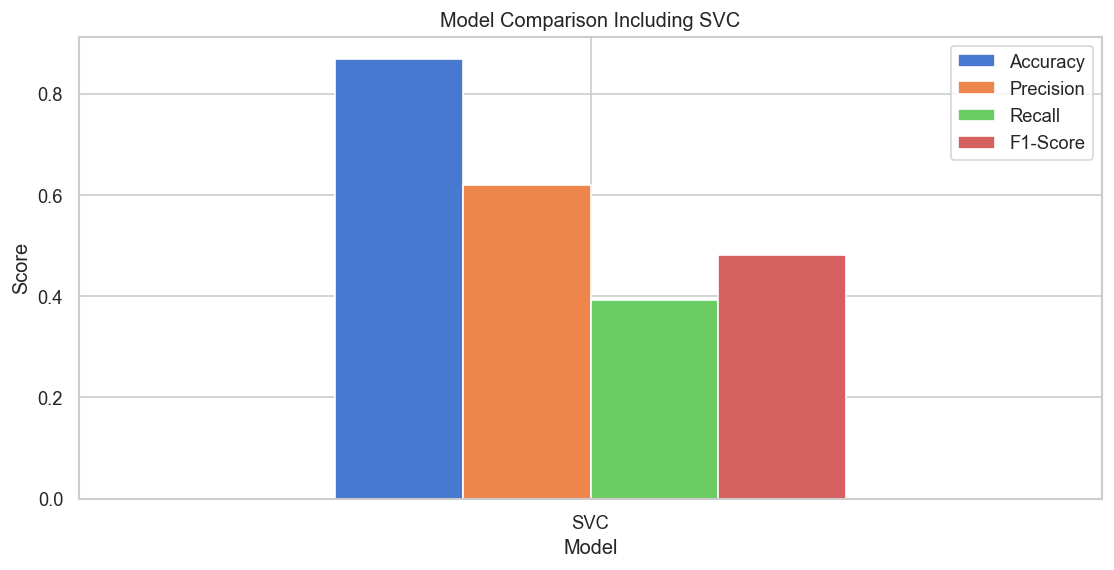

In [21]:
comparison_df.set_index('Model').plot(kind='bar')
plt.title("Model Comparison Including SVC")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

we developed a classification model to predict whether a driver will finish in the top 3 using race and pit stop features. We applied the Support Vector Classifier (SVC) along with proper data preprocessing, cross-validation, and hyperparameter tuning to improve model performance. The tuned SVC model achieved an accuracy of approximately 89%, demonstrating good predictive capability. However, evaluation metrics such as precision, recall, and F1-score revealed that the model performs better on the majority class than the minority class, indicating class imbalance. We then compared SVC with tree-based ensemble methods such as Bagging, Random Forest, and XGBoost, which generally showed better performance due to their ability to capture complex patterns and feature interactions. Overall, this analysis highlights the importance of model selection, tuning, and evaluation using multiple metrics to build an effective classification model for real-world data.

####**How this compare with tree-based methods**


The Support Vector Classifier (SVC) performs well for this classification problem, achieving high overall accuracy. However, when compared to tree-based methods such as Bagging, Random Forest, and XGBoost, there are some key differences. SVC is effective at finding optimal decision boundaries and works well with properly scaled data, but it can struggle with large datasets and complex feature interactions. In contrast, tree-based methods are more flexible and better at capturing nonlinear relationships and interactions between features such as pit stop duration, grid position, and race conditions. Additionally, ensemble methods like Random Forest and XGBoost reduce overfitting and generally provide higher accuracy and better performance on the minority class. Overall, while SVC provides solid results, tree-based models tend to perform better for this problem due to their robustness and ability to handle complex, real-world data more effectively.

### LAB 3 (JACK)

##### Problem

Can we predict whether a driver will finish in the top 3 in a Formula 1 Grand Prix using race context, circuit characteristics, qualifying pace, and pit-stop summaries?

Response variable and predictors:
- Target variable: `top3_finish`
- Candidate predictors:
  - Race features: `year`, `round`, `race_name`
  - Circuit/location: `circuit_name`, `country`, `alt`, `lat`, `lng`
  - Driver/team features: `grid`, `driver_age`, `constructor_name`, `nationality`
  - Pit-stop summaries: `total_pit_stops`, `avg_stop_lap`, `max_pit_duration`, `mean_pit_duration`, `min_pit_duration`

The target is created as a new binary column where `1` means a driver finished in the top 3 and `0` means the driver finished outside the top 3.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

df = f1_driver_classification_df.copy()
y = df["top3_finish"]
X = df.drop(columns=["top3_finish"])

# Detect column types before any encoding
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Classification dataset shape:", df.shape)
print("Numeric features:", len(num_cols), "| Categorical features:", len(cat_cols))
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Class counts:")
print(y.value_counts())

Classification dataset shape: (5970, 17)
Numeric features: 13 | Categorical features: 3
Train shape: (4776, 16) | Test shape: (1194, 16)
Class counts:
top3_finish
0    5052
1     918
Name: count, dtype: int64


#### Data Preparation

Rows, Columns: (5970, 17)

Class balance:


top3_finish
Not Top 3    5052
Top 3         918
Name: count, dtype: int64

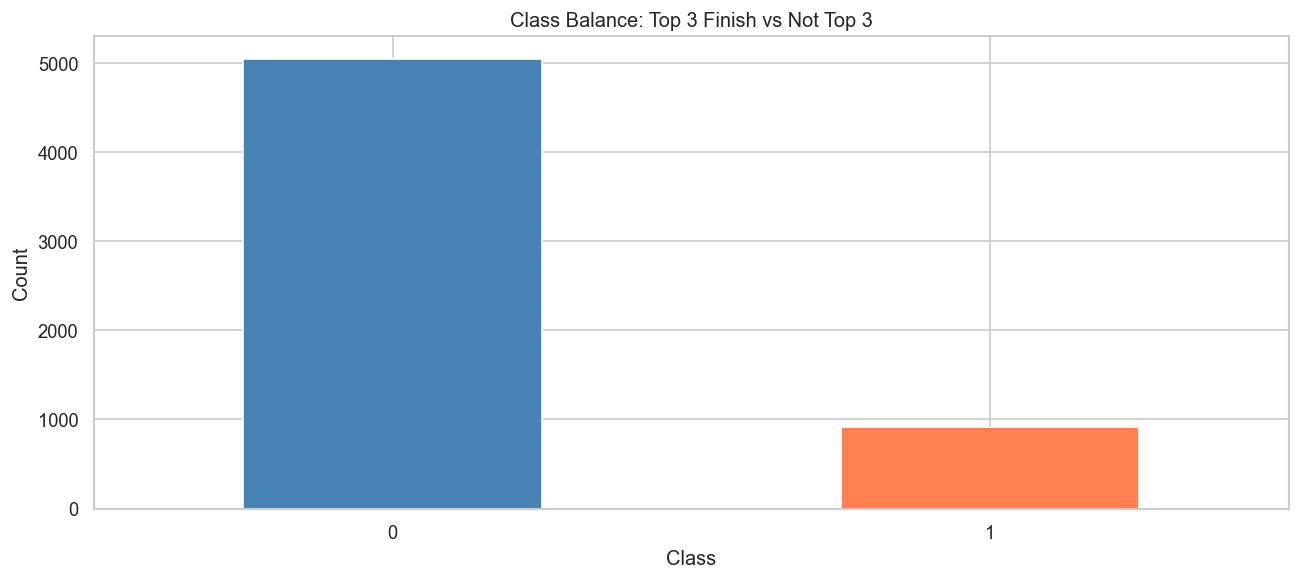


Feature preview:


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


In [27]:
# Data quality and class balance check
print('Rows, Columns:', df.shape)
print('\nClass balance:')
class_counts = df['top3_finish'].value_counts().sort_index()
display(class_counts.rename(index={0: 'Not Top 3', 1: 'Top 3'}))

class_counts.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Class Balance: Top 3 Finish vs Not Top 3')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nFeature preview:')
display(df.head())

#### Training

In [28]:
# 1) Train basic SVC model
svc_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', class_weight='balanced'))
])

svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

acc_svc = accuracy_score(y_test, y_pred_svc)
prec_svc = precision_score(y_test, y_pred_svc, zero_division=0)
rec_svc = recall_score(y_test, y_pred_svc, zero_division=0)
f1_svc = f1_score(y_test, y_pred_svc, zero_division=0)

print('Baseline SVC Metrics')
print(f'Accuracy : {acc_svc:.4f}')
print(f'Precision: {prec_svc:.4f}')
print(f'Recall   : {rec_svc:.4f}')
print(f'F1 Score : {f1_svc:.4f}')

# 2) Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svc_model, X_train, y_train, scoring='accuracy', cv=cv)

print('\nSVC CV Accuracy scores:', np.round(cv_scores, 4))
print(f'Mean CV Accuracy: {cv_scores.mean():.4f}')

# 3) Hyperparameter tuning (GridSearchCV)
param_grid = {
    'model__C': [0.1, 1, 10, 30],
    'model__gamma': ['scale', 0.1, 0.01],
    'model__kernel': ['rbf']
}

grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('model', SVC(class_weight='balanced'))]),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_svc = grid.best_estimator_
y_pred_svc_tuned = best_svc.predict(X_test)

print('\nBest SVC Parameters:', grid.best_params_)
print(f'Best CV Accuracy: {grid.best_score_:.4f}')

# 4) Train tree-based classifiers for comparison
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, random_state=42))
])
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

pos = max((y_train == 1).sum(), 1)
neg = max((y_train == 0).sum(), 1)
scale_pos_weight = neg / pos

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

Baseline SVC Metrics
Accuracy : 0.8576
Precision: 0.5226
Recall   : 0.8804
F1 Score : 0.6559

SVC CV Accuracy scores: [0.8525 0.8565 0.8461 0.8764 0.8492]
Mean CV Accuracy: 0.8562

Best SVC Parameters: {'model__C': 10, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best CV Accuracy: 0.8823


#### Evaluate

Model Performance Comparison (Classification):


,Accuracy,Precision,Recall,F1-Score
Gradient Boosting,0.9079,0.7256,0.6467,0.6839
Random Forest,0.8987,0.7203,0.5598,0.6300
SVC (Tuned),0.8844,0.6127,0.6793,0.6443
XGBoost,0.8777,0.5748,0.7935,0.6667
SVC (Baseline),0.8576,0.5226,0.8804,0.6559



Classification report for tuned SVC:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1010
           1       0.61      0.68      0.64       184

    accuracy                           0.88      1194
   macro avg       0.78      0.80      0.79      1194
weighted avg       0.89      0.88      0.89      1194



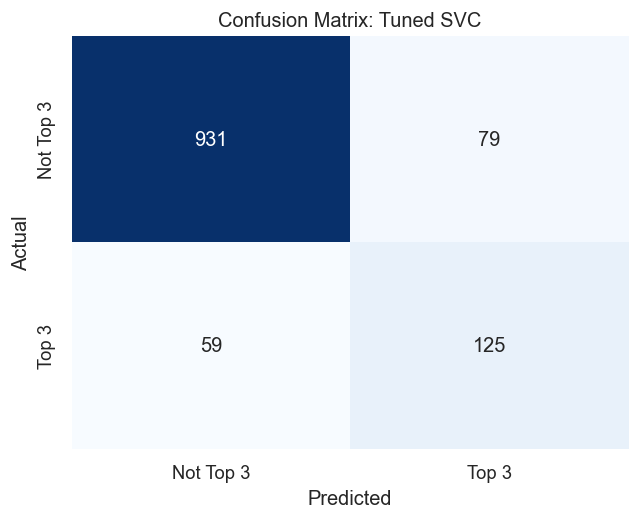

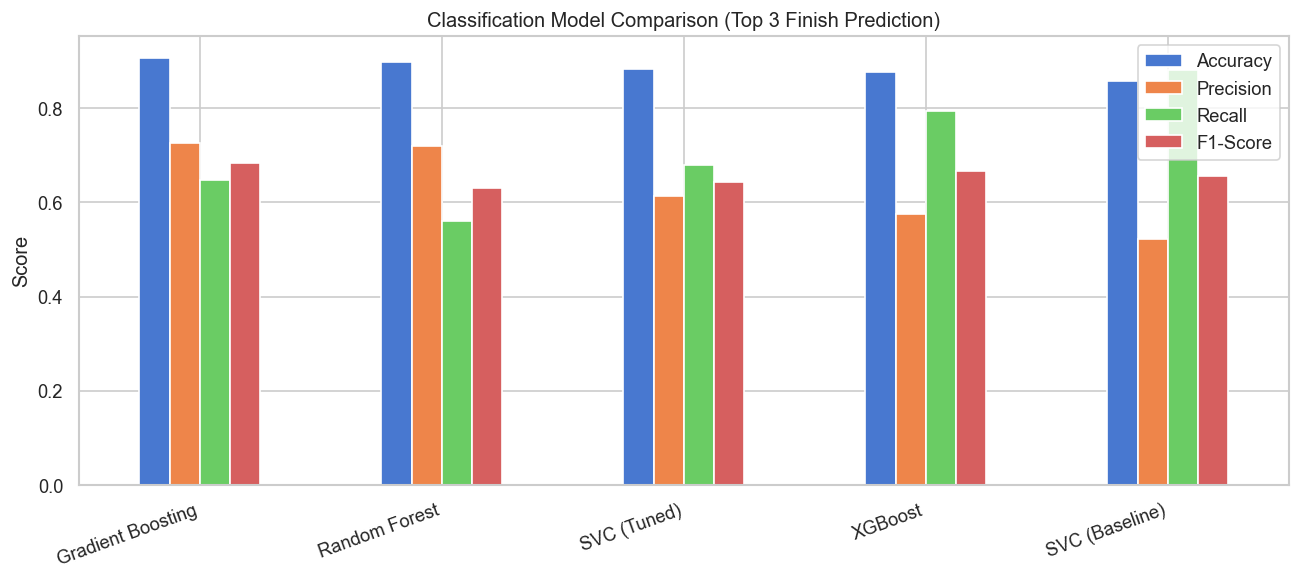

In [29]:
def evaluate_cls(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

results = {
    'SVC (Baseline)': evaluate_cls(y_test, y_pred_svc),
    'SVC (Tuned)': evaluate_cls(y_test, y_pred_svc_tuned),
    'Random Forest': evaluate_cls(y_test, y_pred_rf),
    'Gradient Boosting': evaluate_cls(y_test, y_pred_gb),
    'XGBoost': evaluate_cls(y_test, y_pred_xgb),
}

comparison_df = (
    pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    .T
    .sort_values('Accuracy', ascending=False)
 )

print('Model Performance Comparison (Classification):')
display(comparison_df.round(4))

print('\nClassification report for tuned SVC:')
print(classification_report(y_test, y_pred_svc_tuned, zero_division=0))

cm = confusion_matrix(y_test, y_pred_svc_tuned)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Top 3', 'Top 3'],
            yticklabels=['Not Top 3', 'Top 3'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Tuned SVC')
plt.tight_layout()
plt.show()

ax = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(11, 5))
ax.set_title('Classification Model Comparison (Top 3 Finish Prediction)')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.show()

The SVC model gives a solid baseline for predicting whether a driver finishes in the top 3, especially after scaling numeric features and one-hot encoding categorical features in a pipeline. Cross-validation and GridSearchCV help confirm that the tuned model is more stable than the untuned version.

Compared with tree-based classifiers, SVC handles non-linear boundaries well but can be more sensitive to scaling and parameter choice. Random Forest and XGBoost usually handle mixed feature types and interactions more naturally, so they often perform better or more consistently on this kind of Formula 1 classification problem.

The final model choice should be based on the full set of metrics, especially recall and F1-score for the top-3 class, since accuracy alone can hide class imbalance.